In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

POP_PATH = "/Users/tonytony/Final Project/Data/Raw/population.csv"
META_PATH = "/Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv"

WINDOW_SIZE = 10

print("Libraries imported successfully")
print("Population path:", POP_PATH)
print("Metadata path:", META_PATH)
print("Rolling window size:", WINDOW_SIZE)

Libraries imported successfully
Population path: /Users/tonytony/Final Project/Data/Raw/population.csv
Metadata path: /Users/tonytony/Final Project/Data/Raw/world_bank_country_metadata.csv
Rolling window size: 10


In [2]:
meta_df = pd.read_csv(META_PATH)

region_map = meta_df[[
    "Country Code",
    "World Bank Region"
]].copy().rename(columns={
    "Country Code": "country_code",
    "World Bank Region": "wb_region"
})

region_map["country_type"] = np.where(
    region_map["wb_region"].astype(str).str.strip().eq("Aggregates"),
    "Aggregate",
    "Country/Territory"
)

def load_wdi(path):
    df = pd.read_csv(path, skiprows=4)
    df = df.drop(
        columns=[col for col in df.columns if str(col).startswith("Unnamed")],
        errors="ignore"
    )
    year_cols = [col for col in df.columns if str(col).isdigit()]
    df[year_cols] = df[year_cols].apply(pd.to_numeric, errors="coerce")
    return df

def to_long(df, value_name):
    long_df = df.melt(
        id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
        value_vars=[col for col in df.columns if str(col).isdigit()],
        var_name="year",
        value_name=value_name
    ).rename(columns={
        "Country Name": "country_name",
        "Country Code": "country_code",
        "Indicator Name": "indicator_name",
        "Indicator Code": "indicator_code"
    })

    long_df["year"] = pd.to_numeric(long_df["year"], errors="coerce").astype("int64")
    long_df[value_name] = pd.to_numeric(long_df[value_name], errors="coerce")
    return long_df

def add_region_info(long_df):
    merged = long_df.merge(region_map, on="country_code", how="left")
    merged = merged[merged["country_type"] == "Country/Territory"].copy()
    return merged

def forecast_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))

    non_zero_mask = y_true != 0
    if non_zero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100
    else:
        mape = np.nan

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2
    }

print("Helper functions are ready")
region_map.head()

Helper functions are ready


,country_code,wb_region,country_type
0,ABW,Latin America & Caribbean,Country/Territory
1,AFE,Aggregates,Aggregate
2,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Country/Territory
3,AFR,Aggregates,Aggregate
4,AFW,Aggregates,Aggregate


In [16]:
def format_population_output(df):
    format_map = {}

    for col in ["actual", "predicted", "predicted_population", "actual_population"]:
        if col in df.columns:
            format_map[col] = "{:,.0f}"

    for col in ["MAE", "RMSE", "MAPE_pct", "R_squared"]:
        if col in df.columns:
            format_map[col] = "{:,.4f}"

    return df.style.format(format_map)

In [3]:
pop_raw = load_wdi(POP_PATH)
pop_long = add_region_info(to_long(pop_raw, "population_total"))

pop_long = pop_long[
    (pop_long["population_total"].notna()) &
    (pop_long["population_total"] > 0)
].copy()

print("Population long shape:", pop_long.shape)
print("Countries:", pop_long["country_code"].nunique())
print("Year range:", int(pop_long["year"].min()), "-", int(pop_long["year"].max()))

pop_long.head()

Population long shape: (14075, 8)
Countries: 217
Year range: 1960 - 2024


,country_name,country_code,indicator_name,indicator_code,year,population_total,wb_region,country_type
0,Aruba,ABW,"Population, total",SP.POP.TOTL,1960,54922.0,Latin America & Caribbean,Country/Territory
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,1960,9035043.0,"Middle East, North Africa, Afghanistan & Pakistan",Country/Territory
4,Angola,AGO,"Population, total",SP.POP.TOTL,1960,5231654.0,Sub-Saharan Africa,Country/Territory
5,Albania,ALB,"Population, total",SP.POP.TOTL,1960,1608800.0,Europe & Central Asia,Country/Territory
6,Andorra,AND,"Population, total",SP.POP.TOTL,1960,9510.0,Europe & Central Asia,Country/Territory


In [4]:
population_model_plan = pd.DataFrame({
    "Dataset": ["Population", "Population", "Population"],
    "Candidate Model": ["Naive", "AutoReg", "LogHolt"],
    "Description": [
        "Uses the previous year's population as the forecast.",
        "Uses autoregressive dependence on previous population values.",
        "Uses Holt trend on the log-transformed population series."
    ]
})

population_model_plan

,Dataset,Candidate Model,Description
0,Population,Naive,Uses the previous year's population as the for...
1,Population,AutoReg,Uses autoregressive dependence on previous pop...
2,Population,LogHolt,Uses Holt trend on the log-transformed populat...


In [5]:
def one_step_population_forecast(window_values, model_name, autoreg_lags=3):
    series = pd.Series(window_values, dtype=float)

    if model_name == "Naive":
        return float(series.iloc[-1])

    if model_name == "AutoReg":
        lags = min(autoreg_lags, len(series) - 2)
        if lags < 1:
            return float(series.iloc[-1])

        fit = AutoReg(series, lags=lags, old_names=False, trend="c").fit()
        pred = fit.predict(start=len(series), end=len(series)).iloc[0]
        return float(pred)

    if model_name == "LogHolt":
        log_series = np.log(series)
        fit = ExponentialSmoothing(
            log_series,
            trend="add",
            seasonal=None,
            damped_trend=False
        ).fit()
        pred = fit.forecast(1).iloc[0]
        return float(np.exp(pred))

    raise ValueError(f"Unknown model: {model_name}")

def rolling_population_backtest(
    long_df,
    value_col="population_total",
    candidate_models=None,
    window_size=10,
    min_total_obs=15
):
    if candidate_models is None:
        candidate_models = ["Naive", "AutoReg", "LogHolt"]

    prediction_rows = []
    skipped_rows = []

    grouped = long_df[["country_name", "country_code", "wb_region", "year", value_col]].dropna().groupby("country_code")

    for country_code, group in grouped:
        group = group.sort_values("year").copy()

        if len(group) < max(min_total_obs, window_size + 1):
            skipped_rows.append({
                "country_code": country_code,
                "country_name": group["country_name"].iloc[0],
                "reason": "too_few_observations"
            })
            continue

        values = group[value_col].values.astype(float)
        years = group["year"].values.astype(int)
        country_name = group["country_name"].iloc[0]
        wb_region = group["wb_region"].iloc[0]

        for i in range(window_size, len(group)):
            train_window = values[i - window_size:i]
            actual_value = values[i]
            actual_year = int(years[i])

            for model_name in candidate_models:
                try:
                    predicted_value = one_step_population_forecast(
                        window_values=train_window,
                        model_name=model_name
                    )

                    prediction_rows.append({
                        "Dataset": "Population",
                        "Model": model_name,
                        "country_code": country_code,
                        "country_name": country_name,
                        "wb_region": wb_region,
                        "year": actual_year,
                        "actual": actual_value,
                        "predicted": predicted_value
                    })

                except Exception as e:
                    skipped_rows.append({
                        "country_code": country_code,
                        "country_name": country_name,
                        "reason": f"{model_name} failed at year {actual_year}: {str(e)}"
                    })

    pred_df = pd.DataFrame(prediction_rows)
    skipped_df = pd.DataFrame(skipped_rows)

    summary_rows = []
    if not pred_df.empty:
        for model_name, temp in pred_df.groupby("Model"):
            metrics = forecast_metrics(temp["actual"], temp["predicted"])
            summary_rows.append({
                "Dataset": "Population",
                "Model": model_name,
                **metrics,
                "n_predictions": len(temp),
                "n_countries_modeled": temp["country_code"].nunique()
            })

    summary_df = pd.DataFrame(summary_rows)
    return pred_df, summary_df, skipped_df

print("Population backtest engine is ready")

Population backtest engine is ready


In [17]:
population_predictions, population_summary, population_skipped = rolling_population_backtest(
    long_df=pop_long,
    value_col="population_total",
    candidate_models=["Naive", "AutoReg", "LogHolt"],
    window_size=WINDOW_SIZE,
    min_total_obs=15
)

print("Population candidate model results")
display(population_summary.round(4))

print("Skipped rows:", population_skipped.shape[0])
display(format_population_output(population_predictions.head(15)))

Population candidate model results


,Dataset,Model,MAE,RMSE,MAPE_pct,R_squared,n_predictions,n_countries_modeled
0,Population,AutoReg,332215.6803,1.773138e+07,7.5644,0.9748,11905,217
1,Population,LogHolt,70265.2708,3.165477e+05,0.5801,1.0000,11905,217
2,Population,Naive,394477.9941,1.553770e+06,1.8174,0.9998,11905,217


Skipped rows: 0


,Dataset,Model,country_code,country_name,wb_region,year,actual,predicted
0,Population,Naive,ABW,Aruba,Latin America & Caribbean,1970,"58,950","59,052"
1,Population,AutoReg,ABW,Aruba,Latin America & Caribbean,1970,"58,950","58,914"
2,Population,LogHolt,ABW,Aruba,Latin America & Caribbean,1970,"58,950","59,035"
3,Population,Naive,ABW,Aruba,Latin America & Caribbean,1971,"58,781","58,950"
4,Population,AutoReg,ABW,Aruba,Latin America & Caribbean,1971,"58,781","58,821"
5,Population,LogHolt,ABW,Aruba,Latin America & Caribbean,1971,"58,781","59,337"
6,Population,Naive,ABW,Aruba,Latin America & Caribbean,1972,"58,047","58,781"
7,Population,AutoReg,ABW,Aruba,Latin America & Caribbean,1972,"58,047","58,618"
8,Population,LogHolt,ABW,Aruba,Latin America & Caribbean,1972,"58,047","59,061"
9,Population,Naive,ABW,Aruba,Latin America & Caribbean,1973,"58,299","58,047"


In [18]:
population_summary_sorted = population_summary.sort_values(["RMSE", "MAE", "MAPE_pct"]).reset_index(drop=True)
best_population_model = population_summary_sorted.head(1).copy()

print("Sorted Population model results")
display(population_summary_sorted.round(4))

print("Best Population model")
display(best_population_model.style.format({
    "MAE": "{:,.4f}",
    "RMSE": "{:,.4f}",
    "MAPE_pct": "{:,.4f}",
    "R_squared": "{:,.4f}"
}))

Sorted Population model results


,Dataset,Model,MAE,RMSE,MAPE_pct,R_squared,n_predictions,n_countries_modeled
0,Population,LogHolt,70265.2708,3.165477e+05,0.5801,1.0000,11905,217
1,Population,Naive,394477.9941,1.553770e+06,1.8174,0.9998,11905,217
2,Population,AutoReg,332215.6803,1.773138e+07,7.5644,0.9748,11905,217


Best Population model


,Dataset,Model,MAE,RMSE,MAPE_pct,R_squared,n_predictions,n_countries_modeled
0,Population,LogHolt,"70,265.2708","316,547.7427",0.5801,1.0000,11905,217


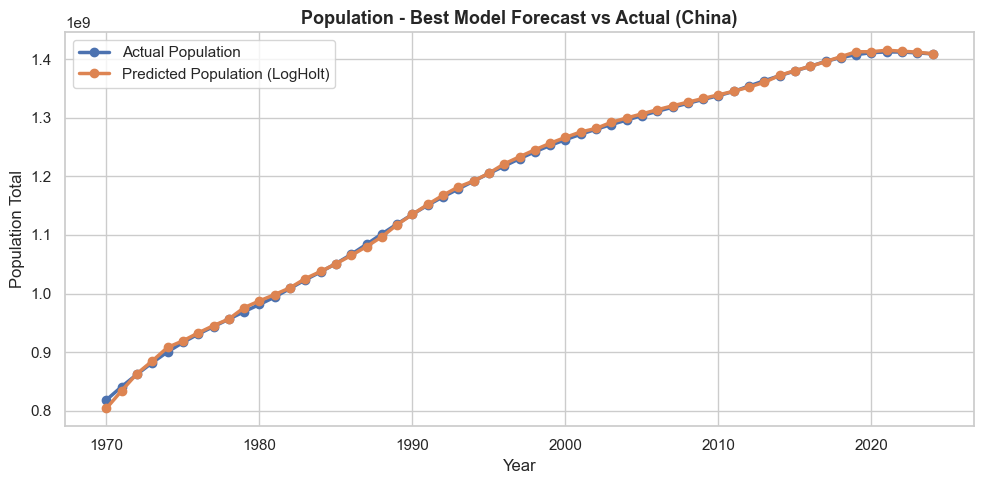

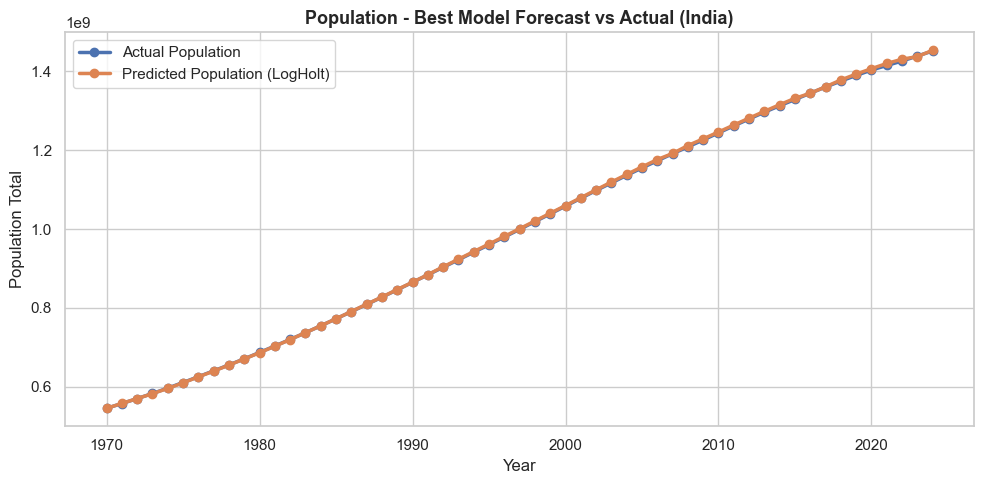

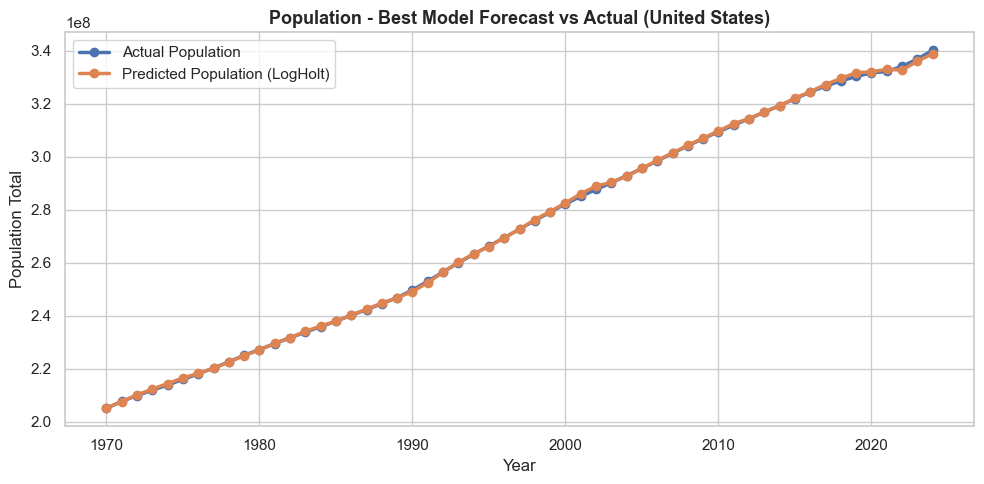

In [8]:
best_population_model_name = best_population_model["Model"].iloc[0]

best_population_predictions = population_predictions[
    population_predictions["Model"] == best_population_model_name
].copy()

sample_countries = (
    best_population_predictions.groupby(["country_code", "country_name"])["actual"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .reset_index()
)

for _, row in sample_countries.iterrows():
    code = row["country_code"]
    name = row["country_name"]

    temp = best_population_predictions[
        best_population_predictions["country_code"] == code
    ].sort_values("year")

    plt.figure(figsize=(10, 5))
    plt.plot(temp["year"], temp["actual"], marker="o", linewidth=2.5, label="Actual Population")
    plt.plot(temp["year"], temp["predicted"], marker="o", linewidth=2.5, label=f"Predicted Population ({best_population_model_name})")

    plt.title(f"Population - Best Model Forecast vs Actual ({name})", fontsize=13, fontweight="bold")
    plt.xlabel("Year")
    plt.ylabel("Population Total")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [19]:
final_population_prediction_table = best_population_predictions[[
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "actual",
    "predicted"
]].copy()

display(format_population_output(final_population_prediction_table.head(15)))

,country_name,country_code,wb_region,year,actual,predicted
2,Aruba,ABW,Latin America & Caribbean,1970,"58,950","59,035"
5,Aruba,ABW,Latin America & Caribbean,1971,"58,781","59,337"
8,Aruba,ABW,Latin America & Caribbean,1972,"58,047","59,061"
11,Aruba,ABW,Latin America & Caribbean,1973,"58,299","58,164"
14,Aruba,ABW,Latin America & Caribbean,1974,"58,349","58,375"
17,Aruba,ABW,Latin America & Caribbean,1975,"58,295","58,408"
20,Aruba,ABW,Latin America & Caribbean,1976,"58,368","58,150"
23,Aruba,ABW,Latin America & Caribbean,1977,"58,580","58,050"
26,Aruba,ABW,Latin America & Caribbean,1978,"58,776","58,132"
29,Aruba,ABW,Latin America & Caribbean,1979,"59,191","58,738"


In [11]:
SAVE_POP_SUMMARY_PATH = "/Users/tonytony/Final Project/Data/Cleaned/population_time_series_model_selection_summary_10y.csv"
SAVE_POP_PREDICTIONS_PATH = "/Users/tonytony/Final Project/Data/Cleaned/population_time_series_model_selection_predictions_10y.csv"
SAVE_POP_BEST_MODEL_PATH = "/Users/tonytony/Final Project/Data/Cleaned/population_time_series_best_model_10y.csv"

population_summary_sorted.to_csv(SAVE_POP_SUMMARY_PATH, index=False)
final_population_prediction_table.to_csv(SAVE_POP_PREDICTIONS_PATH, index=False)
best_population_model.to_csv(SAVE_POP_BEST_MODEL_PATH, index=False)

print("Saved summary to:")
print(SAVE_POP_SUMMARY_PATH)

print("\nSaved best-model predictions to:")
print(SAVE_POP_PREDICTIONS_PATH)

print("\nSaved best-model row to:")
print(SAVE_POP_BEST_MODEL_PATH)

Saved summary to:
/Users/tonytony/Final Project/Data/Cleaned/population_time_series_model_selection_summary_10y.csv

Saved best-model predictions to:
/Users/tonytony/Final Project/Data/Cleaned/population_time_series_model_selection_predictions_10y.csv

Saved best-model row to:
/Users/tonytony/Final Project/Data/Cleaned/population_time_series_best_model_10y.csv


In [12]:
COUNTRY_CODE_INPUT = "VNM"
TARGET_YEAR_INPUT = 2030

BEST_BACKTEST_MODEL = best_population_model_name
FUTURE_PROJECTION_MODEL = "LogHolt"

print("Country code:", COUNTRY_CODE_INPUT)
print("Target year:", TARGET_YEAR_INPUT)
print("Best one-step backtest model:", BEST_BACKTEST_MODEL)
print("Future projection model:", FUTURE_PROJECTION_MODEL)
print("Reason: population grows smoothly over time, so LogHolt is used for future projection to preserve compounding trend.")


Country code: VNM
Target year: 2030
Selected best model: LogHolt


In [13]:
def forecast_population_to_target_year(
    long_df,
    country_code,
    target_year,
    model_name,
    value_col="population_total",
    window_size=10
):
    country_df = (
        long_df[long_df["country_code"] == country_code][
            ["country_name", "country_code", "wb_region", "year", value_col]
        ]
        .dropna()
        .sort_values("year")
        .copy()
    )

    if country_df.empty:
        raise ValueError(f"Country code {country_code} not found")

    country_name = country_df["country_name"].iloc[0]
    wb_region = country_df["wb_region"].iloc[0]

    year_value_map = dict(zip(country_df["year"].astype(int), country_df[value_col].astype(float)))
    available_years = sorted(year_value_map.keys())
    last_actual_year = max(available_years)

    if len(available_years) < window_size:
        raise ValueError(f"Not enough data for {country_code}. Need at least {window_size} observations.")

    forecast_rows = []

    if target_year <= last_actual_year:
        needed_years = list(range(target_year - window_size, target_year))
        missing_years = [y for y in needed_years if y not in year_value_map]

        if missing_years:
            raise ValueError(f"Missing historical years for direct forecast: {missing_years}")

        train_window = [year_value_map[y] for y in needed_years]
        predicted_value = one_step_population_forecast(
            window_values=train_window,
            model_name=model_name
        )

        actual_value = year_value_map.get(target_year, np.nan)

        result_df = pd.DataFrame([{
            "country_name": country_name,
            "country_code": country_code,
            "wb_region": wb_region,
            "target_year": target_year,
            "window_start_year": needed_years[0],
            "window_end_year": needed_years[-1],
            "model_used": model_name,
            "predicted_population": predicted_value,
            "actual_population": actual_value,
            "forecast_type": "direct_from_historical_window"
        }])

        return result_df

    history_map = year_value_map.copy()

    for year_to_predict in range(last_actual_year + 1, target_year + 1):
        available_hist_years = sorted(history_map.keys())

        if len(available_hist_years) < window_size:
            raise ValueError("Not enough historical values to continue recursive forecast")

        window_years = available_hist_years[-window_size:]
        train_window = [history_map[y] for y in window_years]

        predicted_value = one_step_population_forecast(
            window_values=train_window,
            model_name=model_name
        )

        history_map[year_to_predict] = float(predicted_value)

        forecast_rows.append({
            "country_name": country_name,
            "country_code": country_code,
            "wb_region": wb_region,
            "target_year": year_to_predict,
            "window_start_year": window_years[0],
            "window_end_year": window_years[-1],
            "model_used": model_name,
            "predicted_population": predicted_value,
            "actual_population": np.nan,
            "forecast_type": "recursive_future_forecast"
        })

    result_df = pd.DataFrame(forecast_rows)
    return result_df

In [20]:
target_population_forecast_df = forecast_population_to_target_year(
    long_df=pop_long,
    country_code=COUNTRY_CODE_INPUT,
    target_year=TARGET_YEAR_INPUT,
    model_name=FUTURE_PROJECTION_MODEL,
    value_col="population_total",
    window_size=WINDOW_SIZE
)

display(format_population_output(target_population_forecast_df))


,country_name,country_code,wb_region,target_year,window_start_year,window_end_year,model_used,predicted_population,actual_population,forecast_type
0,Viet Nam,VNM,East Asia & Pacific,2025,2015,2024,LogHolt,"101,938,191",nan,recursive_future_forecast
1,Viet Nam,VNM,East Asia & Pacific,2026,2016,2025,LogHolt,"102,860,168",nan,recursive_future_forecast
2,Viet Nam,VNM,East Asia & Pacific,2027,2017,2026,LogHolt,"103,745,771",nan,recursive_future_forecast
3,Viet Nam,VNM,East Asia & Pacific,2028,2018,2027,LogHolt,"104,522,816",nan,recursive_future_forecast
4,Viet Nam,VNM,East Asia & Pacific,2029,2019,2028,LogHolt,"105,325,947",nan,recursive_future_forecast
5,Viet Nam,VNM,East Asia & Pacific,2030,2020,2029,LogHolt,"106,149,854",nan,recursive_future_forecast


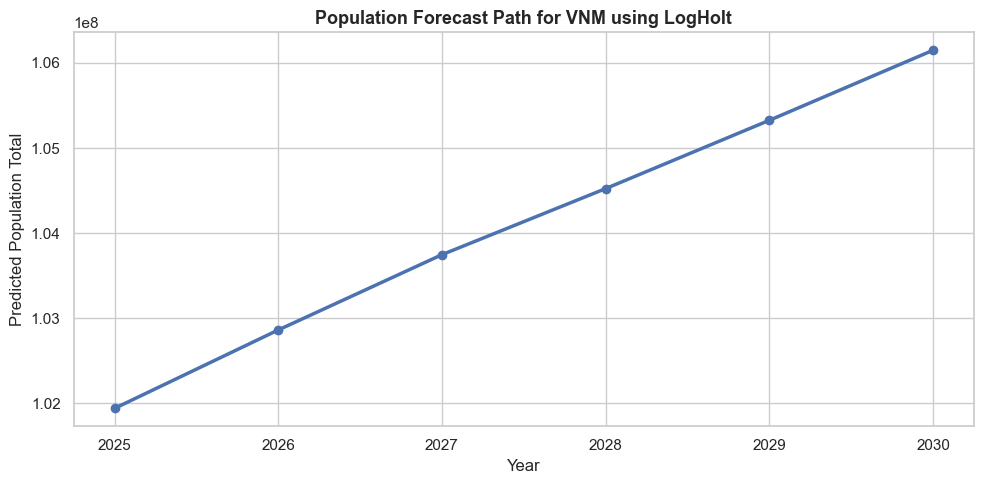

In [15]:
if TARGET_YEAR_INPUT > pop_long["year"].max():
    plt.figure(figsize=(10, 5))
    plt.plot(
        target_population_forecast_df["target_year"],
        target_population_forecast_df["predicted_population"],
        marker="o",
        linewidth=2.5
    )
    plt.title(f"Population Forecast Path for {COUNTRY_CODE_INPUT} using {FUTURE_PROJECTION_MODEL}", fontsize=13, fontweight="bold")
    plt.xlabel("Year")
    plt.ylabel("Predicted Population Total")
    plt.tight_layout()
    plt.show()
else:
    print("Target year is inside the historical dataset, so only one direct forecast row is shown above.")
